In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option("display.max.columns", None)
pd.set_option('display.width', 180)
pd.set_option("display.precision", 4)
pd.set_option('future.no_silent_downcasting', True)

# Load merged dataset
dir_path = 'C:/thesis_python'
absolute_path = dir_path + '/Output files/'

merged_df = pd.read_csv(absolute_path + 'Merged_dataset.csv')

# Calculate Loneliness Score with normalization for different scales
loneliness_cols = ['Loneliness_1', 'Loneliness_2', 'Loneliness_3', 'Loneliness_4', 'Loneliness_5', 'Loneliness_6']
for col in loneliness_cols:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

def calculate_loneliness_score(data, loneliness_cols):
    reverse_cols = ['Loneliness_2', 'Loneliness_3', 'Loneliness_4']
    # reverse coding
    for col in reverse_cols:
        data[col]= data[col].apply(lambda x: 4-x if pd.notna(x) else x)
    # code 1=yes or 2=more or less -> 1, 3=no -> 0
    for col in loneliness_cols:
        data[col + '_dich'] = data[col].apply(lambda x: 1 if x in [1,2] else (0 if x == 3 else np.nan))

    # sum of scores
    dich_cols = [col + '_dich' for col in loneliness_cols]
    data['Loneliness_Score'] = data[dich_cols].sum(axis=1, min_count=6)
    return data


# Calculate life loneliness score
merged_df = calculate_loneliness_score(merged_df, loneliness_cols)



# 1. MHI-5 scores calculation
MHI_cols = ['MHI_1', 'MHI_2', 'MHI_3', 'MHI_4', 'MHI_5']
for col in MHI_cols:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

def calculate_mhi_score(data, MHI_cols):
    reverse_cols = ['MHI_3', 'MHI_5']
    # reverse coding
    for col in reverse_cols:
        data[col] = data[col].apply(lambda x: 7 - x if pd.notna(x) else np.nan)
    data['MHI_Score'] = data[MHI_cols].mean(axis=1, skipna=True)
    return data

merged_df = calculate_mhi_score(merged_df, MHI_cols)

# 2. Life satisfaction
Life_Satisfaction_cols = ['LS_1', 'LS_2', 'LS_3', 'LS_4', 'LS_5']
for col in Life_Satisfaction_cols:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

def calculate_ls_score(data, Life_Satisfaction_cols):
    data['Life_Satisfaction_Score'] = data[Life_Satisfaction_cols].mean(axis=1, skipna=True)
    return data

merged_df = calculate_ls_score(merged_df, Life_Satisfaction_cols)


# 3. Big 5
# Define reverse scoring function
def reverse_score_5_likert(x):
    return 6 - x if pd.notna(x) else x

# Define items per trait
traits = {
    'Extraversion': {
        'pos': ['BIG-V_1','BIG-V_11','BIG-V_21','BIG-V_31','BIG-V_41'],
        'neg': ['BIG-V_6','BIG-V_16','BIG-V_26','BIG-V_36','BIG-V_46']
    },
    'Agreeableness': {
        'pos': ['BIG-V_7','BIG-V_17','BIG-V_27','BIG-V_37','BIG-V_42','BIG-V_47'],
        'neg': ['BIG-V_2','BIG-V_12','BIG-V_22','BIG-V_32']
    },
    'Conscientiousness': {
        'pos': ['BIG-V_3','BIG-V_13','BIG-V_23','BIG-V_33','BIG-V_43','BIG-V_48'],
        'neg': ['BIG-V_8','BIG-V_18','BIG-V_28','BIG-V_38']
    },
    'Emotional_Stability': {
        'pos': ['BIG-V_9','BIG-V_19'],
        'neg': ['BIG-V_4','BIG-V_14','BIG-V_24','BIG-V_29','BIG-V_34','BIG-V_39','BIG-V_44','BIG-V_49']
    },
    'Intellect_Imagination': {
        'pos': ['BIG-V_5','BIG-V_15','BIG-V_25','BIG-V_35','BIG-V_40','BIG-V_45','BIG-V_50'],
        'neg': ['BIG-V_10','BIG-V_20','BIG-V_30']
    }
}

# Reverse negative items
for trait, items in traits.items():
    for col in items['neg']:
        merged_df[col] = merged_df[col].apply(reverse_score_5_likert)

# Average scores per trait
for trait, items in traits.items():
    merged_df[trait] = merged_df[items['pos'] + items['neg']].mean(axis=1, skipna=True)


# 4. Self-esteem
self_esteem_cols = ['Self-esteem_1', 'Self-esteem_2', 'Self-esteem_3', 'Self-esteem_4', 'Self-esteem_5', 'Self-esteem_6', 
                 'Self-esteem_7', 'Self-esteem_8', 'Self-esteem_9', 'Self-esteem_10']
for col in self_esteem_cols:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

def calculate_selfesteem_score(data, self_esteem_cols):
    reverse_cols = ['Self-esteem_3', 'Self-esteem_5', 'Self-esteem_8', 'Self-esteem_9', 'Self-esteem_10']
    # reverse coding
    for col in reverse_cols:
        data[col] = data[col].apply(lambda x: 8 - x if pd.notna(x) else np.nan)
    data['Self_esteem_Score'] = data[self_esteem_cols].mean(axis=1, skipna=True)
    return data

merged_df = calculate_selfesteem_score(merged_df, self_esteem_cols)

# 5. Optimism
optimism_cols = ['Optimism_1', 'Optimism_2', 'Optimism_3', 'Optimism_4', 'Optimism_5', 'Optimism_6', 
                 'Optimism_7', 'Optimism_8', 'Optimism_9', 'Optimism_10']

def calculate_optimism_score(data, optimism_cols):
    reverse_cols = ['Optimism_3', 'Optimism_7', 'Optimism_9']
    # reverse coding
    for col in reverse_cols:
        data[col] = data[col].apply(lambda x: 6 - x if pd.notna(x) else np.nan)
    data['Optimism_Score'] = data[optimism_cols].mean(axis=1, skipna=True)
    
    return data

merged_df = calculate_optimism_score(merged_df, optimism_cols)

In [5]:
# Basic data exploration
print(merged_df.info())
print(merged_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196832 entries, 0 to 196831
Columns: 122 entries, nomem_encr to Optimism_Score
dtypes: float64(120), int64(2)
memory usage: 183.2 MB
None
        nomem_encr         Year  Health Perception       MHI_1       MHI_2       MHI_3       MHI_4       MHI_5  Leisure_Satisfaction  Loneliness_1  Loneliness_2  Loneliness_3  \
count  196832.0000  196832.0000         97010.0000  96845.0000  96844.0000  96844.0000  96844.0000  96844.0000           100517.0000    99704.0000    99704.0000    99704.0000   
mean   850056.1868    2015.4945             3.1154      2.1615      1.7023      2.7711      2.0561      2.7581               18.5359        2.7035        2.7025        2.5079   
std     28800.8701       5.1678             0.7792      1.0262      0.9676      1.0846      1.0295      1.0683              105.4091        0.5421        0.5519        0.6600   
min    800000.0000    2007.0000             1.0000      1.0000      1.0000      1.0000      1.0000  

In [6]:
columns = ['nomem_encr','Year', 'Age', 'Nr household members', 'Gender', 'Partner', 'Household Income', 'Urbanity', 'Education Level',
           'Children living-at-home',  'Occupation', 'Health Perception', 'MHI_Score', 'Leisure_Satisfaction', 'Social_Satisfaction',
           'Family_Evening', 'Neighborhood_Evening', 'Others_Evening', 'Subjective_Happiness', 'Life_Satisfaction_Score', 'Extraversion',
            'Agreeableness', 'Conscientiousness', 'Emotional_Stability', 'Intellect_Imagination', 'Self_esteem_Score', 'Optimism_Score', 'Loneliness_Score',
]

merged_df = merged_df[columns]


In [7]:
# Summary of missing data
missing_summary = merged_df.isnull().sum().sort_values(ascending=False)
print("Top missing columns:\n", missing_summary.head(15))

Top missing columns:
 Optimism_Score             129116
Self_esteem_Score          124558
Intellect_Imagination      124317
Agreeableness              124317
Emotional_Stability        124316
Conscientiousness          124316
Extraversion               124316
Life_Satisfaction_Score    104557
Subjective_Happiness       104485
MHI_Score                   99987
Health Perception           99822
Neighborhood_Evening        97719
Others_Evening              97678
Family_Evening              97556
Social_Satisfaction         97452
dtype: int64


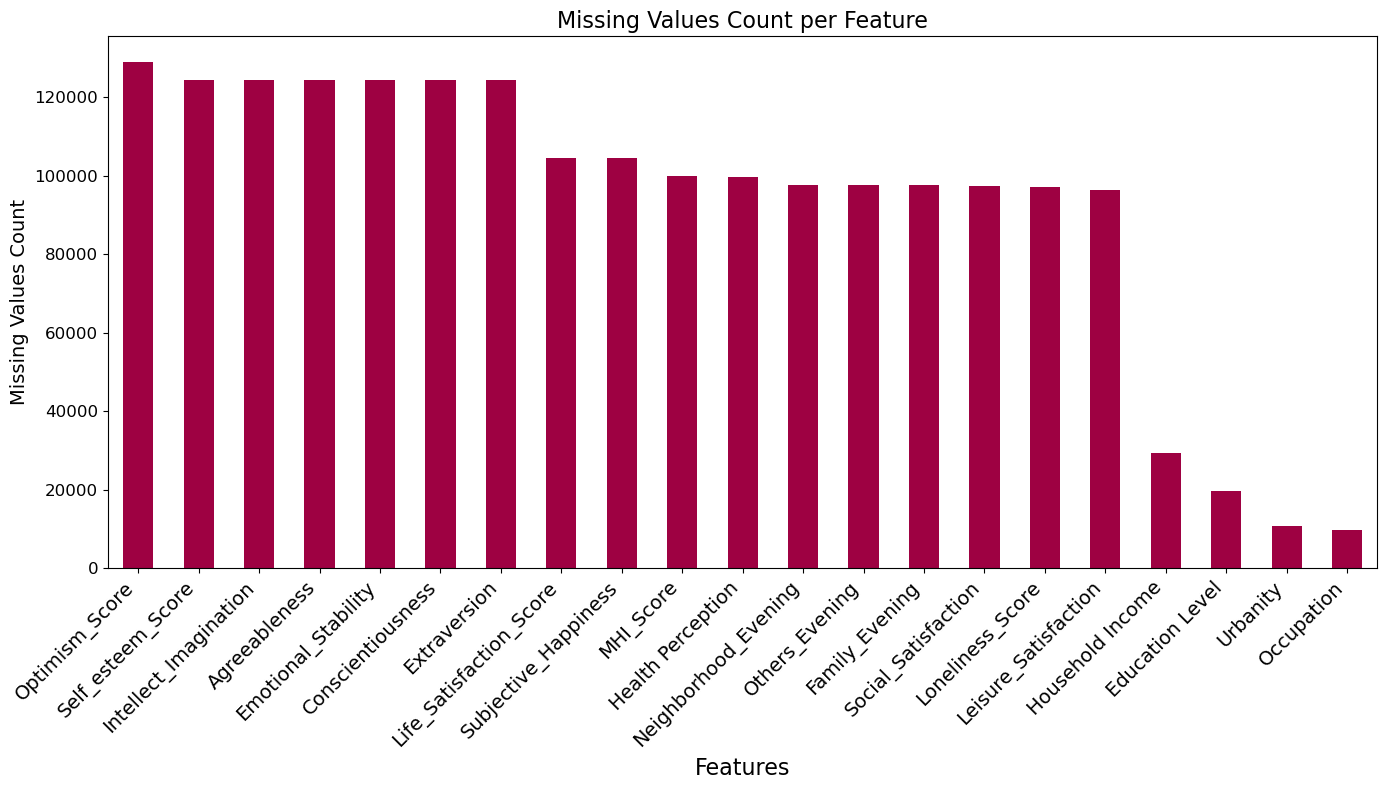

In [10]:
# Plot Missing Values (Before) only for selected columns
plt.figure(figsize=(14, 8))
missing_before = merged_df.isnull().sum()
missing_before = missing_before[missing_before > 0]
missing_before.sort_values(ascending=False)[:-5].plot(kind='bar', colormap='Spectral')
plt.title('Missing Values Count per Feature', fontsize=16)
plt.ylabel('Missing Values Count', fontsize= 14)
plt.yticks(fontsize= 12)
plt.xlabel('Features', fontsize= 16)
plt.xticks(rotation=45, ha='right', fontsize= 14)
plt.tight_layout()
plt.show()

In [11]:
# Descriptive statistics for participants
descriptive_stats = merged_df.describe(include='all')
print(descriptive_stats)

              Year          Age  Nr household members       Gender      Partner  Household Income     Urbanity  Education Level  Children living-at-home   Occupation  \
count  196832.0000  187061.0000           187061.0000  187061.0000  187061.0000        1.6743e+05  185966.0000      177053.0000              187061.0000  187044.0000   
mean     2015.4945      41.6294                3.0147       1.5086       0.7673        5.2494e+03       2.9844           3.3192                   1.1687       5.2190   
std         5.1678      22.3902                1.4303       0.5007       0.4225        1.5319e+04       1.5631           1.6665                   1.2536       3.9865   
min      2007.0000       0.0000                1.0000       1.0000       0.0000        0.0000e+00     -99.0000           1.0000                   0.0000       1.0000   
25%      2011.0000      23.0000                2.0000       1.0000       1.0000        2.9086e+03       2.0000           2.0000                   0.0000   

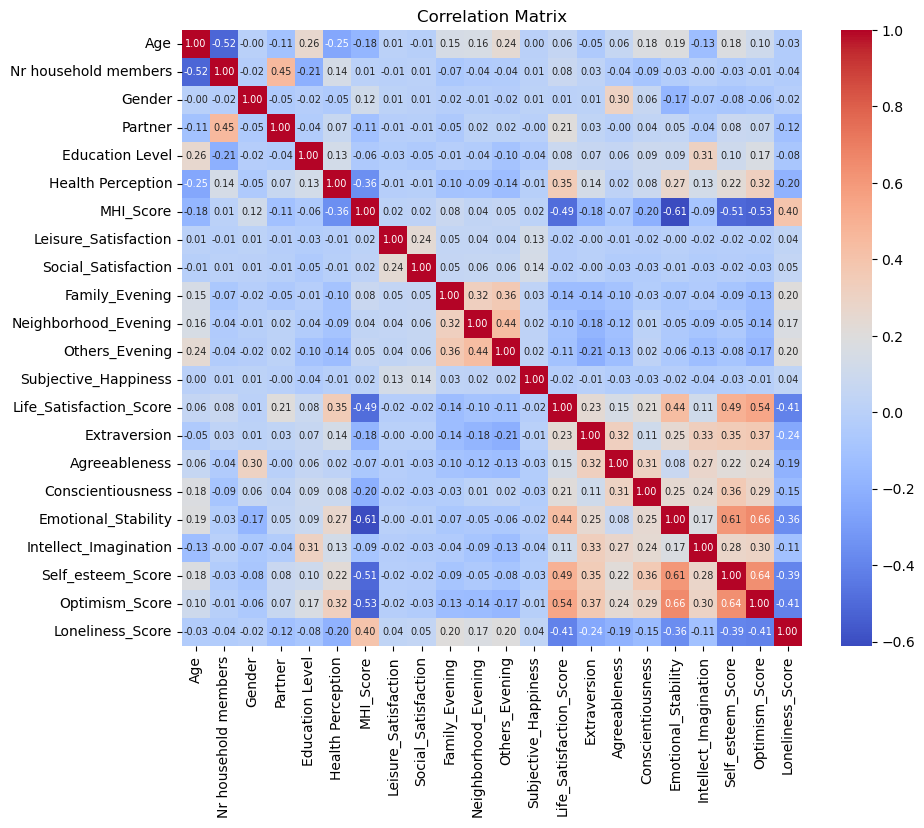

In [8]:
heatmap_columns = ['Age', 'Nr household members', 'Gender', 'Partner', 'Education Level', 'Health Perception', 'MHI_Score', 'Leisure_Satisfaction', 'Social_Satisfaction',
           'Family_Evening', 'Neighborhood_Evening', 'Others_Evening', 'Subjective_Happiness', 'Life_Satisfaction_Score', 'Extraversion',
            'Agreeableness', 'Conscientiousness', 'Emotional_Stability', 'Intellect_Imagination', 'Self_esteem_Score', 'Optimism_Score', 'Loneliness_Score',
]

corr_matrix = merged_df[heatmap_columns].corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    annot_kws={"size": 7}  
)
plt.title("Correlation Matrix", fontsize=12)  
plt.xticks(fontsize=10)  
plt.yticks(fontsize=10)  
plt.show()


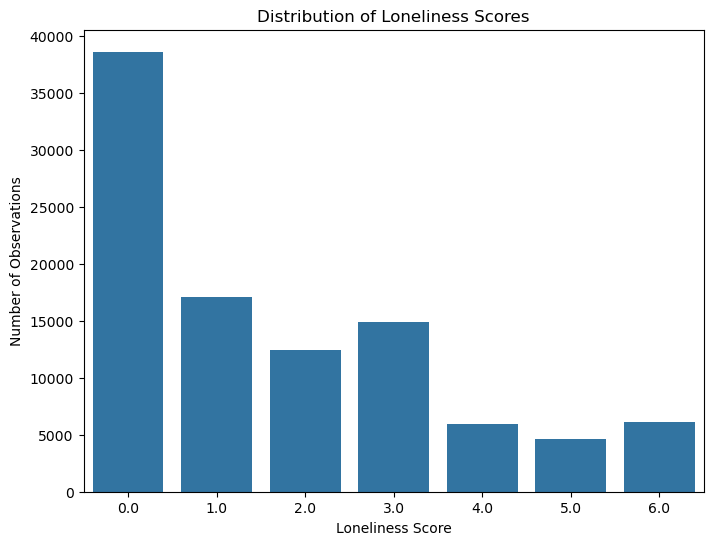

In [9]:
# Frequencies of loneliness scores
loneliness_counts = (
    merged_df['Loneliness_Score']
    .value_counts()
    .sort_index()
    .reset_index()
)

loneliness_counts.columns = ['Loneliness_Score', 'Count']

# Plot
plt.figure(figsize=(8,6))
sns.barplot(
    x='Loneliness_Score',
    y='Count',
    data=loneliness_counts,
)

plt.xlabel('Loneliness Score')
plt.ylabel('Number of Observations')
plt.title('Distribution of Loneliness Scores')
plt.show()


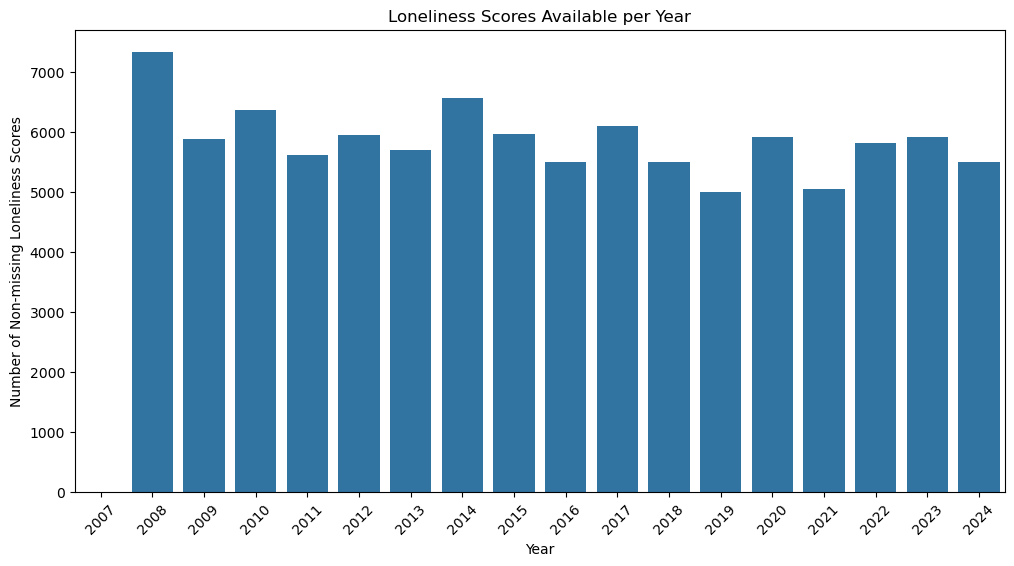

In [10]:
# Non-missing Loneliness_Score per year
loneliness_counts = merged_df.groupby('Year')['Loneliness_Score'].count().reset_index()
loneliness_counts.rename(columns={'Loneliness_Score':'N_Loneliness'}, inplace=True)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='Year', y='N_Loneliness', data=loneliness_counts)
plt.xticks(rotation=45)
plt.ylabel('Number of Non-missing Loneliness Scores')
plt.title('Loneliness Scores Available per Year')
plt.show()


In [11]:
# Loneliness missing values per year
df_loneliness = merged_df[merged_df['Loneliness_Score'].notna()]
counts_per_year = df_loneliness.groupby('Year')['nomem_encr'].count()
print(counts_per_year)


Year
2008    7339
2009    5889
2010    6365
2011    5613
2012    5957
2013    5707
2014    6570
2015    5968
2016    5492
2017    6102
2018    5500
2019    5005
2020    5918
2021    5048
2022    5815
2023    5923
2024    5492
Name: nomem_encr, dtype: int64


In [12]:

counts_per_year = merged_df['Year'].value_counts().sort_index()
print(counts_per_year)


Year
2007     6698
2008    12534
2009    13627
2010    11588
2011    11798
2012    10541
2013    10777
2014    12044
2015    10705
2016     9551
2017    11769
2018    10263
2019    10031
2020    10787
2021     9884
2022    11332
2023    11915
2024    10988
Name: count, dtype: int64


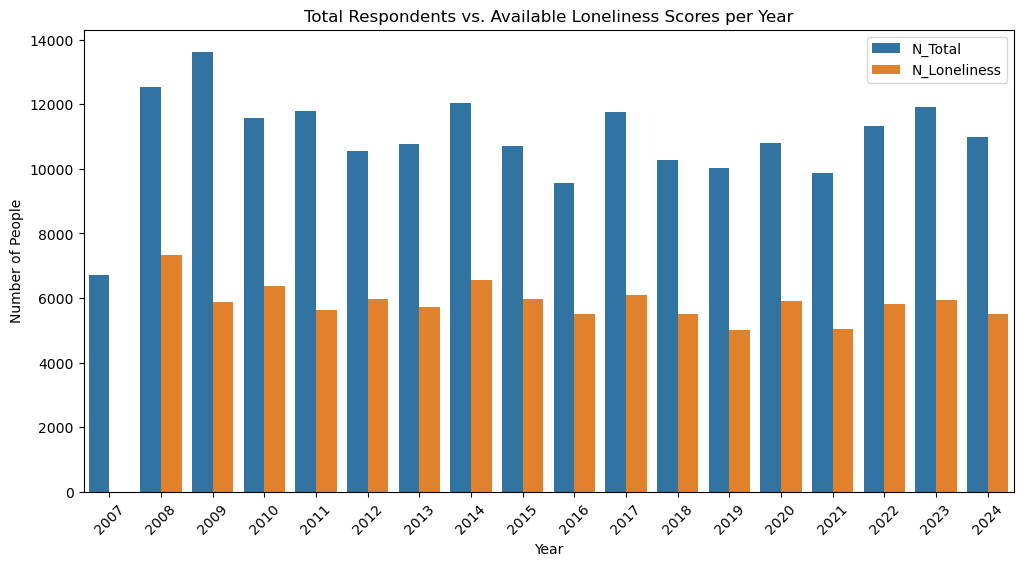

In [13]:
# Total respondents per year
total_counts = merged_df.groupby('Year')['nomem_encr'].count().reset_index()
total_counts.rename(columns={'nomem_encr': 'N_Total'}, inplace=True)

# Non-missing loneliness per year
loneliness_counts = merged_df.groupby('Year')['Loneliness_Score'].count().reset_index()
loneliness_counts.rename(columns={'Loneliness_Score': 'N_Loneliness'}, inplace=True)

# Merge
counts = total_counts.merge(loneliness_counts, on='Year')
counts_long = counts.melt(id_vars='Year',
                          value_vars=['N_Total', 'N_Loneliness'],
                          var_name='Type',
                          value_name='Count')

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='Year', y='Count', hue='Type', data=counts_long)

plt.xticks(rotation=45)
plt.ylabel('Number of People')
plt.title('Total Respondents vs. Available Loneliness Scores per Year')
plt.legend(title='')
plt.show()


In [14]:
 #percentage missing values
missing_rates = df_loneliness.isna().mean() * 100
missing_rates = missing_rates.sort_values(ascending=False)

print(missing_rates)


Optimism_Score             39.0339
Self_esteem_Score          34.6208
Intellect_Imagination      34.4734
Emotional_Stability        34.4734
Conscientiousness          34.4734
Agreeableness              34.4734
Extraversion               34.4734
MHI_Score                  16.3556
Health Perception          16.2653
Life_Satisfaction_Score    15.9925
Subjective_Happiness       15.9524
Household Income           10.8582
Urbanity                    2.4914
Education Level             2.2918
Occupation                  2.0320
Partner                     2.0210
Age                         2.0210
Nr household members        2.0210
Children living-at-home     2.0210
Gender                      2.0210
Neighborhood_Evening        0.5918
Others_Evening              0.5506
Family_Evening              0.4283
Social_Satisfaction         0.3420
Leisure_Satisfaction        0.2507
nomem_encr                  0.0000
Year                        0.0000
Loneliness_Score            0.0000
dtype: float64


In [15]:
# Calculate missing percentage per row
df_loneliness['missing_pct'] = df_loneliness[columns].isna().mean(axis=1)

# See distribution
df_loneliness['missing_pct'].describe()



C:\Users\cheye\AppData\Local\Temp\ipykernel_22096\3555316227.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_loneliness['missing_pct'] = df_loneliness[columns].isna().mean(axis=1)


count    99703.0000
mean         0.1216
std          0.1464
min          0.0000
25%          0.0000
50%          0.0357
75%          0.2143
max          0.8929
Name: missing_pct, dtype: float64

In [16]:
df_loneliness['nomem_encr'].nunique()


18360

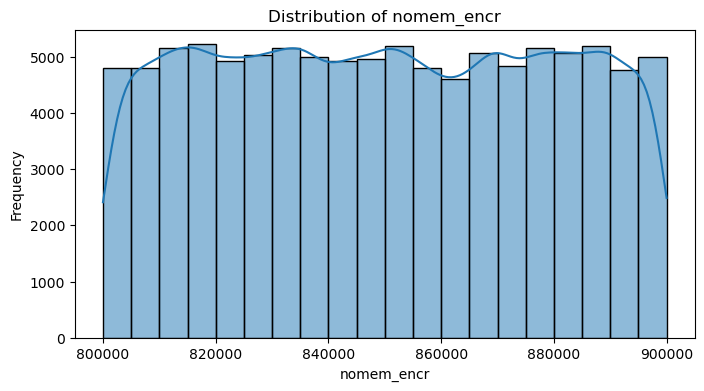

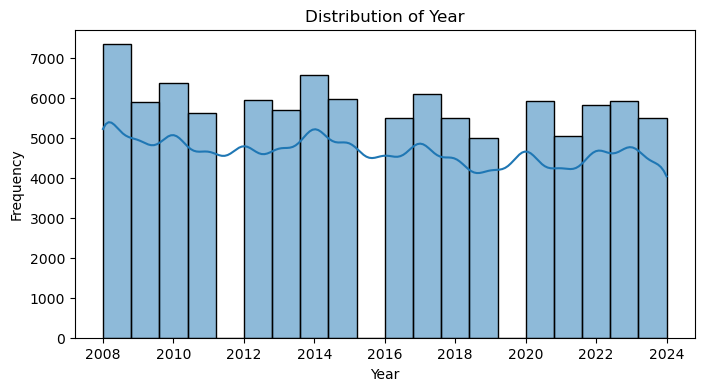

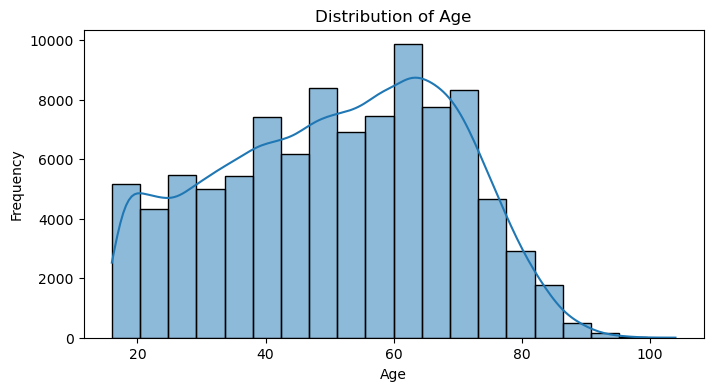

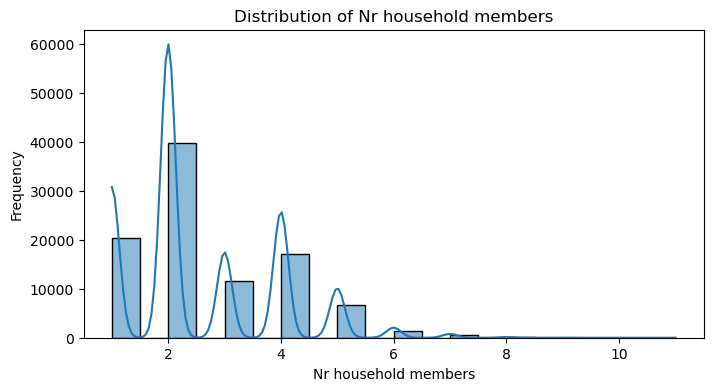

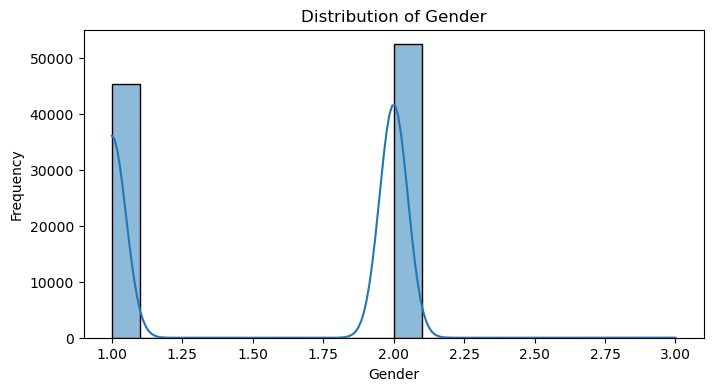

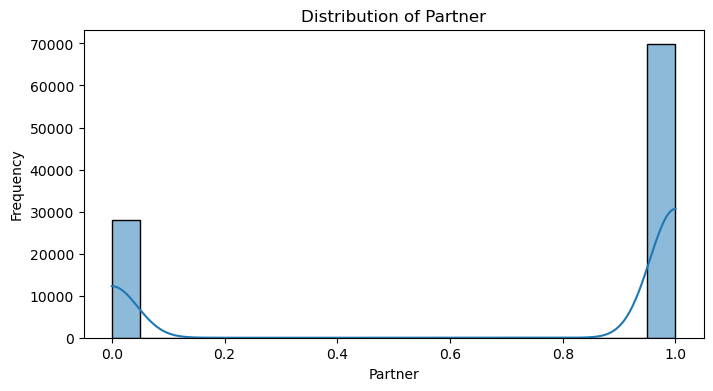

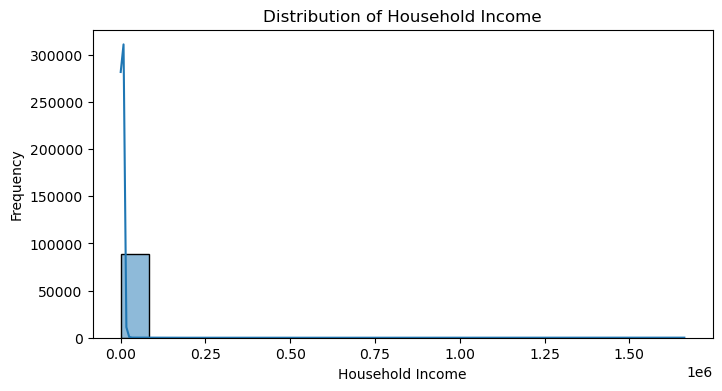

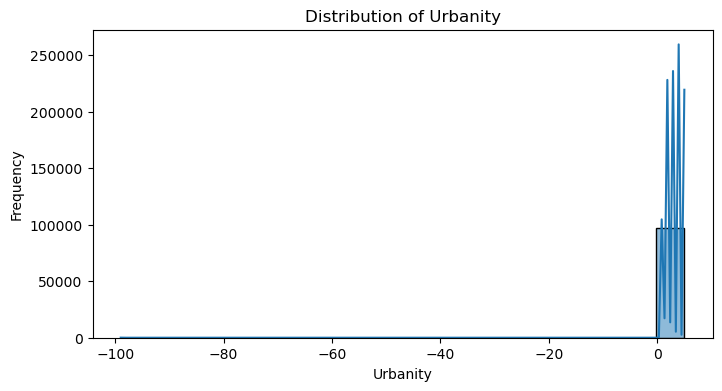

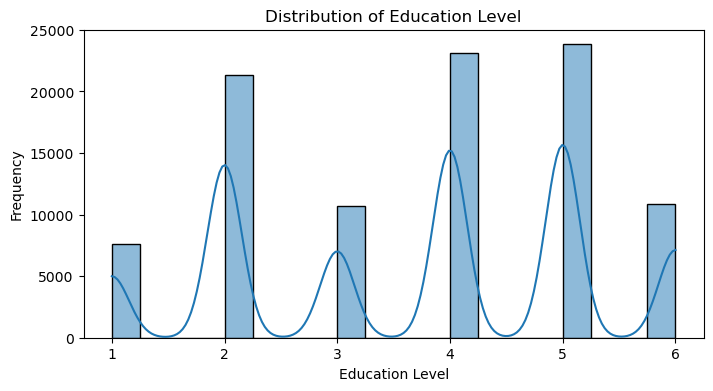

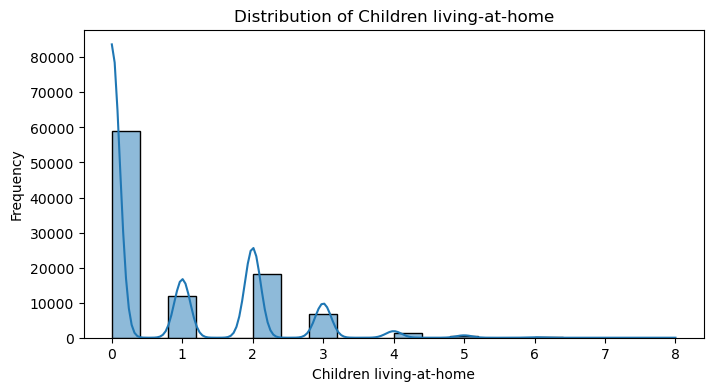

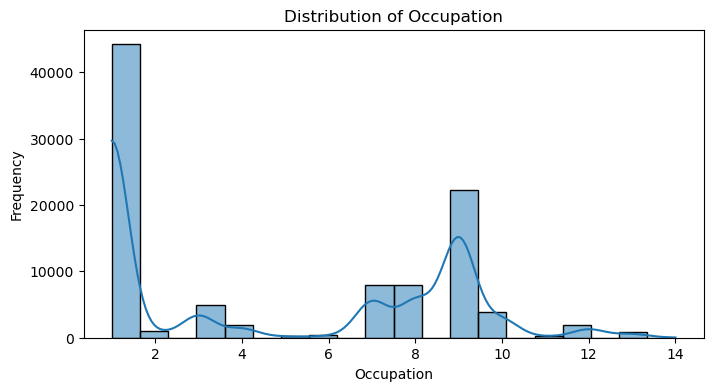

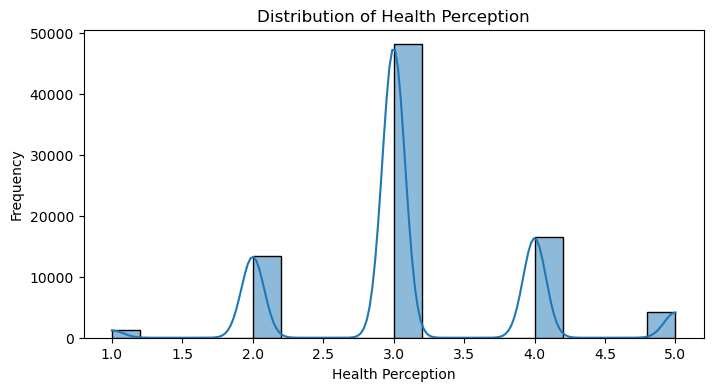

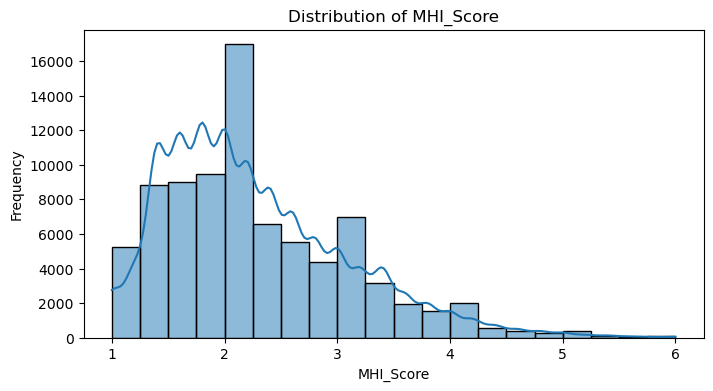

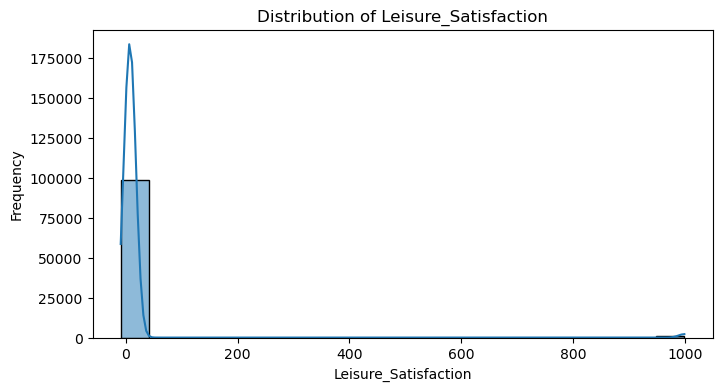

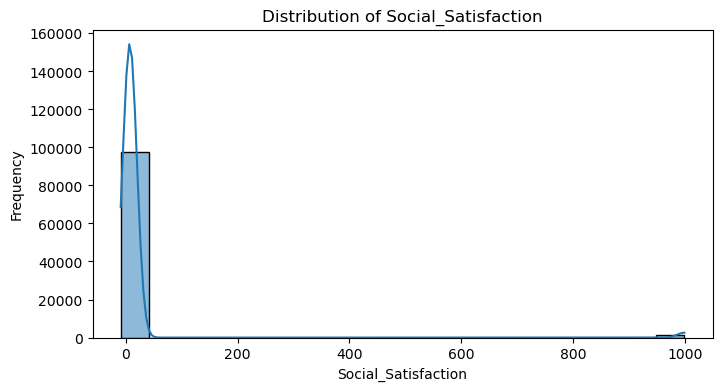

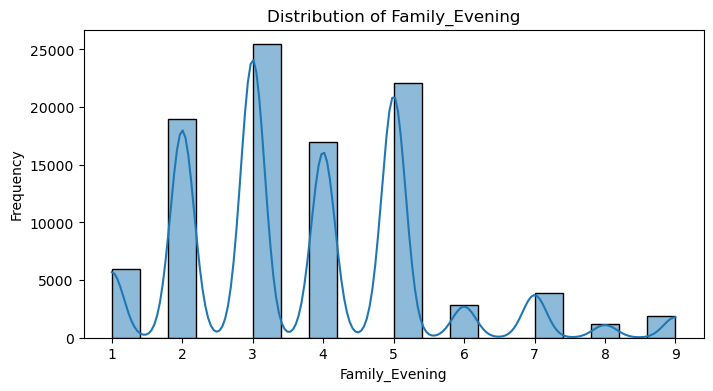

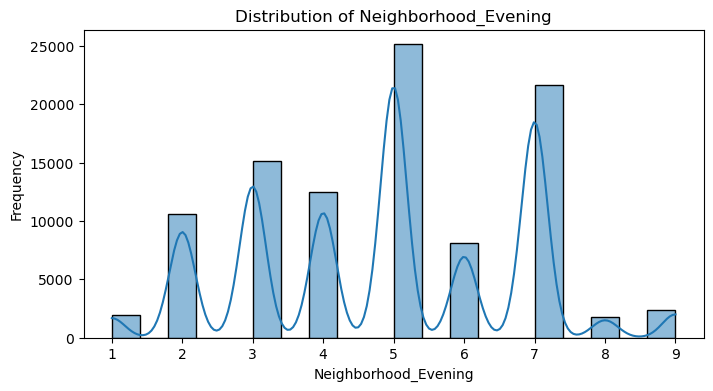

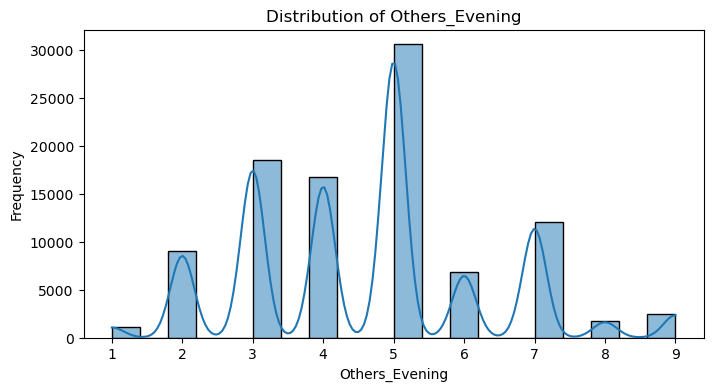

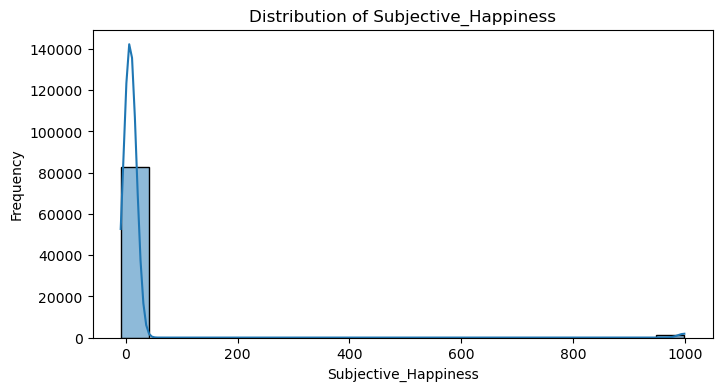

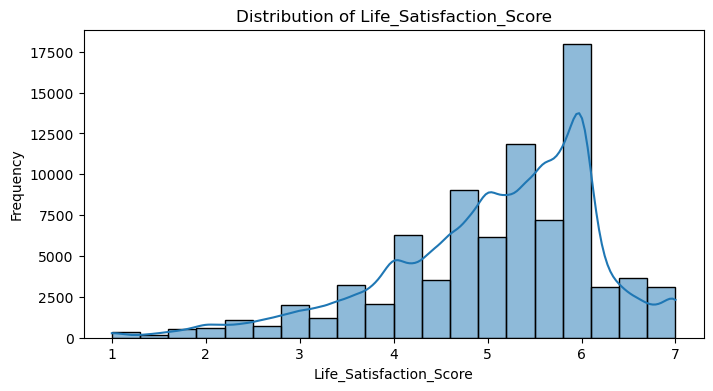

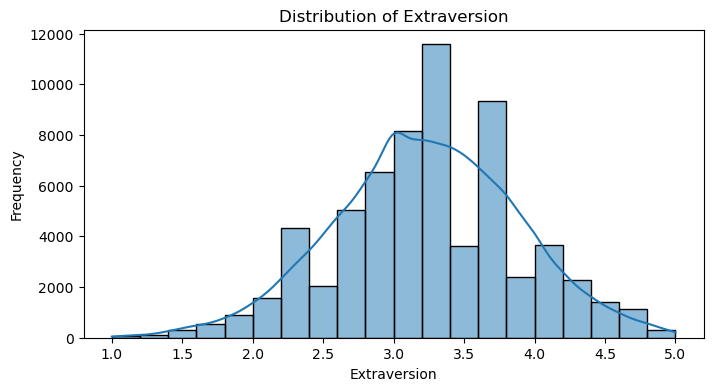

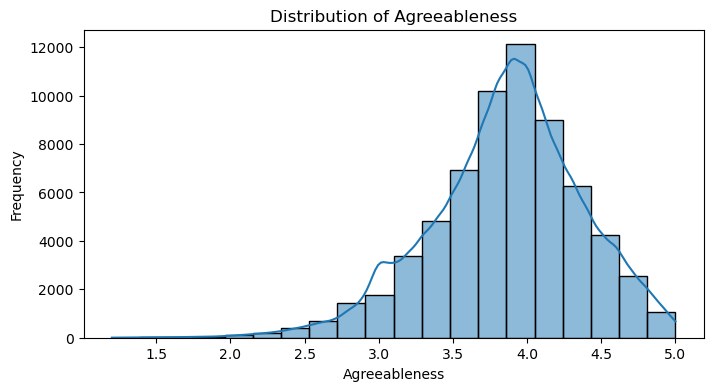

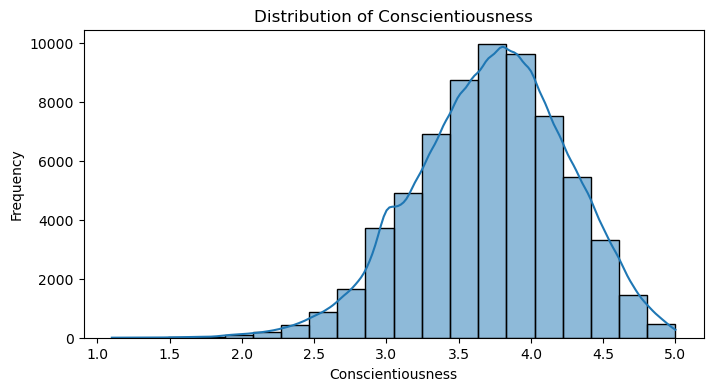

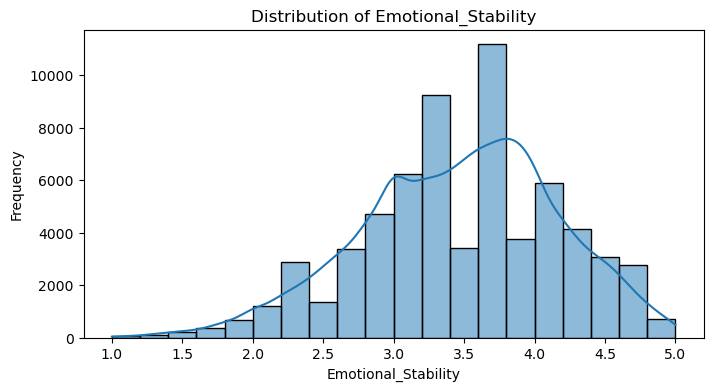

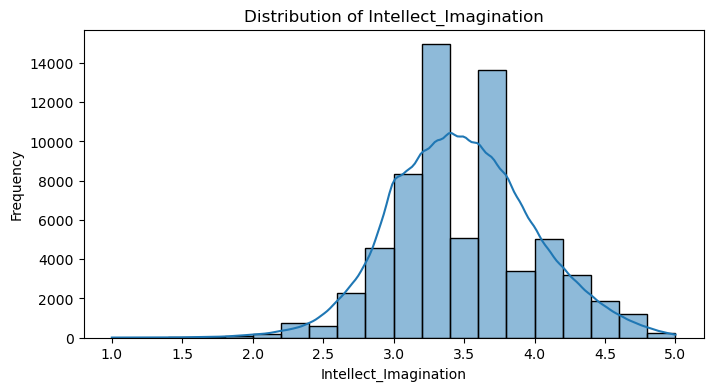

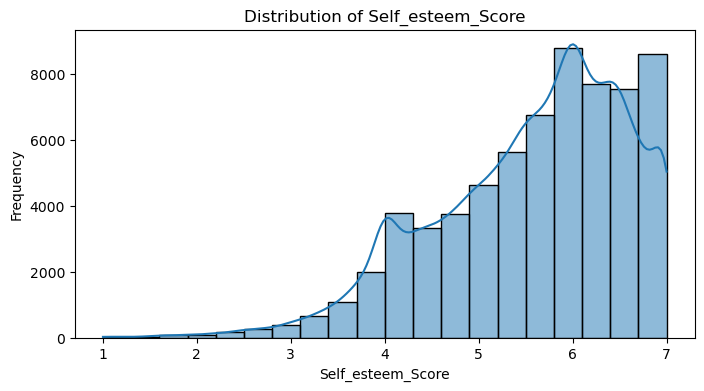

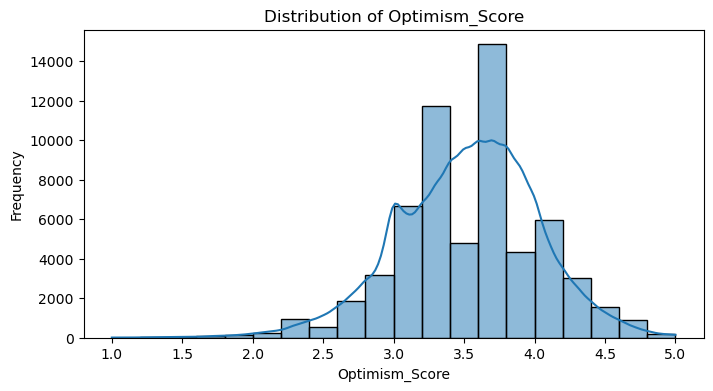

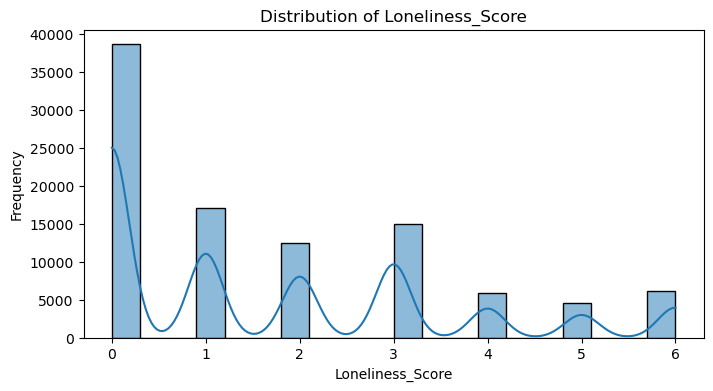

In [19]:
# plots of features
for col in columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df_loneliness[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()